In [9]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import joblib
import os, sys, logging
from model import predict_conditional, FlexibleNN

# Some evaluations in the cross sections

Here we evaluate the model over the real values of the cross sections

In [10]:
# Pallete for plotting
from matplotlib.colors import LinearSegmentedColormap
colorlist = [(0,0,0),(20,33,61),(252,163,17),(229,229,229),(255,255,255)]
colorlist = [[float(e)/255 for e in c] for c in colorlist]
mi_gradiente = LinearSegmentedColormap.from_list("mi_paleta", colorlist)

colorlist2 = [(244,241,222),(224,122,95),(61,64,91),(129,178,154),(242,204,143)]
colorlist2 = [[float(e)/255 for e in c] for c in colorlist2]
mi_gradiente2 = LinearSegmentedColormap.from_list("mi_paleta", colorlist2)


paleta = [{"name":"Ink Black","hex":"001219","rgb":[0,18,25],"cmyk":[100,28,0,90],"hsb":[197,100,10],"hsl":[197,100,5],"lab":[5,-4,-6]},
 {"name":"Dark Teal","hex":"005f73","rgb":[0,95,115],"cmyk":[100,17,0,55],"hsb":[190,100,45],"hsl":[190,100,23],"lab":[37,-16,-18]},
 {"name":"Dark Cyan","hex":"0a9396","rgb":[10,147,150],"cmyk":[93,2,0,41],"hsb":[181,93,59],"hsl":[181,88,31],"lab":[55,-30,-11]},
 {"name":"Pearl Aqua","hex":"94d2bd","rgb":[148,210,189],"cmyk":[30,0,10,18],"hsb":[160,30,82],"hsl":[160,41,70],"lab":[80,-24,4]},
 {"name":"Vanilla Custard","hex":"e9d8a6","rgb":[233,216,166],"cmyk":[0,7,29,9],"hsb":[45,29,91],"hsl":[45,60,78],"lab":[87,-2,27]},
 {"name":"Golden Orange","hex":"ee9b00","rgb":[238,155,0],"cmyk":[0,35,100,7],"hsb":[39,100,93],"hsl":[39,100,47],"lab":[71,22,75]},
 {"name":"Burnt Caramel","hex":"ca6702","rgb":[202,103,2],"cmyk":[0,49,99,21],"hsb":[30,99,79],"hsl":[30,98,40],"lab":[54,34,62]},
 {"name":"Rusty Spice","hex":"bb3e03","rgb":[187,62,3],"cmyk":[0,67,98,27],"hsb":[19,98,73],"hsl":[19,97,37],"lab":[44,48,55]},
 {"name":"Oxidized Iron","hex":"ae2012","rgb":[174,32,18],"cmyk":[0,82,90,32],"hsb":[5,90,68],"hsl":[5,81,38],"lab":[38,55,44]},
 {"name":"Brown Red","hex":"9b2226","rgb":[155,34,38],"cmyk":[0,78,75,39],"hsb":[358,78,61],"hsl":[358,64,37],"lab":[35,49,29]}]
colorlist3 = []
for p in paleta:
    colorlist3.append(p["rgb"])

colorlist3 = [[float(e)/255 for e in c] for c in colorlist3]
mi_gradiente3 = LinearSegmentedColormap.from_list("mi_paleta", colorlist3)

In [11]:
# Load the model
DEVICE = torch.device('cpu')
MODEL_FOLDER = os.path.join('.','models_folder')

encoder = joblib.load(os.path.join(MODEL_FOLDER, 'one_hot_encoder_models.joblib'))
# model = FlexibleNN(6, 128, "gauss", 0.0)
# model.load_state_dict(torch.load(os.path.join(MODEL_FOLDER,'best_statedict_gauss_128_128_128.pth'),map_location=DEVICE))

model = FlexibleNN(6, 128, "gauss", 0.0)
model.load_state_dict(torch.load(os.path.join(MODEL_FOLDER,'best_statedict_gauss_128_128_128_hole_3.pth'),map_location=DEVICE))
model.eval()
print('Theoretical models trained:', encoder.categories_)

Theoretical models trained: [array(['CDW-EIS', 'CTMC', 'Semiempiric_1985Rudd'], dtype=object)]


In [12]:
# Load the databases to check the metrics
from db_reader import read_all_databases

namelist = [os.path.join('.','dbs','Semiempiric_db', 'semiempiric_TCS_database_single_ionization_atoms_1985Rudd.csv'),
            os.path.join('.','dbs','ctmc', 'ctmc_TCS_database_single_ionization_hydrogen.csv'),
            os.path.join('.','dbs','CDWEIS', 'cdw-eis_TCS_database_single_ionization_atoms_except_Kr.csv')]


df =read_all_databases(namelist)

# --- Prepare the Data ---
df['log_E'] = np.log10(df['E_proj[keV/u]'])
df['log_sigma'] = np.log10(df['Cross_section[cm2]'])

# One-hot encode Theory_ID

# --- Data for the Conditional NN with Z_target = 1 ---
hyd_df = df[df['Z_target']==1]
theory_one_hot = encoder.transform(hyd_df[['Theory_ID']].values)
hyd_df.columns

Index(['Z_ion', 'Z_target', 'E_proj[keV/u]', 'Cross_section[cm2]',
       'Uncertainty[%]', 'is_exp', 'Theory_ID', 'DOI', 'log_E', 'log_sigma'],
      dtype='object')

In [13]:
# Useful metrics 

def abs_err(y_pred, ground_truth):
    return np.abs(ground_truth-y_pred)

def rel_err(y_pred, ground_truth):
    return abs_err(y_pred, ground_truth)/np.abs(ground_truth)

def MAE(predictions, ground_truth):
    return torch.mean(torch.abs(predictions-ground_truth)).item()

def RMSE(predictions, ground_truth):
    return torch.sqrt(torch.mean((predictions-ground_truth)**2)).item()

def MBE(predictions, ground_truth):
    return torch.mean(predictions-ground_truth).item()

def MRE(predictions, ground_truth):
    return torch.mean(torch.abs((predictions-ground_truth)/ground_truth)).item()

def MaxAE(predictions, ground_truth):
    return torch.max(torch.abs(predictions-ground_truth)).item()

def MaxRE(predictions, ground_truth):
    return torch.max(torch.abs((predictions-ground_truth)/ground_truth)).item()

/tmp/ipykernel_257197/940030964.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_lp = predict_conditional(model, encoder, theory, z_ion, 1, np.log10(x_to_predict)).reshape(-1)
/tmp/ipykernel_257197/940030964.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_lp = predict_conditional(model, encoder, theory, z_ion, 1, np.log10(x_to_predict)).reshape(-1)
/tmp/ipykernel_257197/940030964.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred_lp = predict_conditional(model, encoder, theory, z_ion, 1, np.log10(x_to_predict)).reshape(-1)
/tmp/ipykernel_257197/940030964.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated

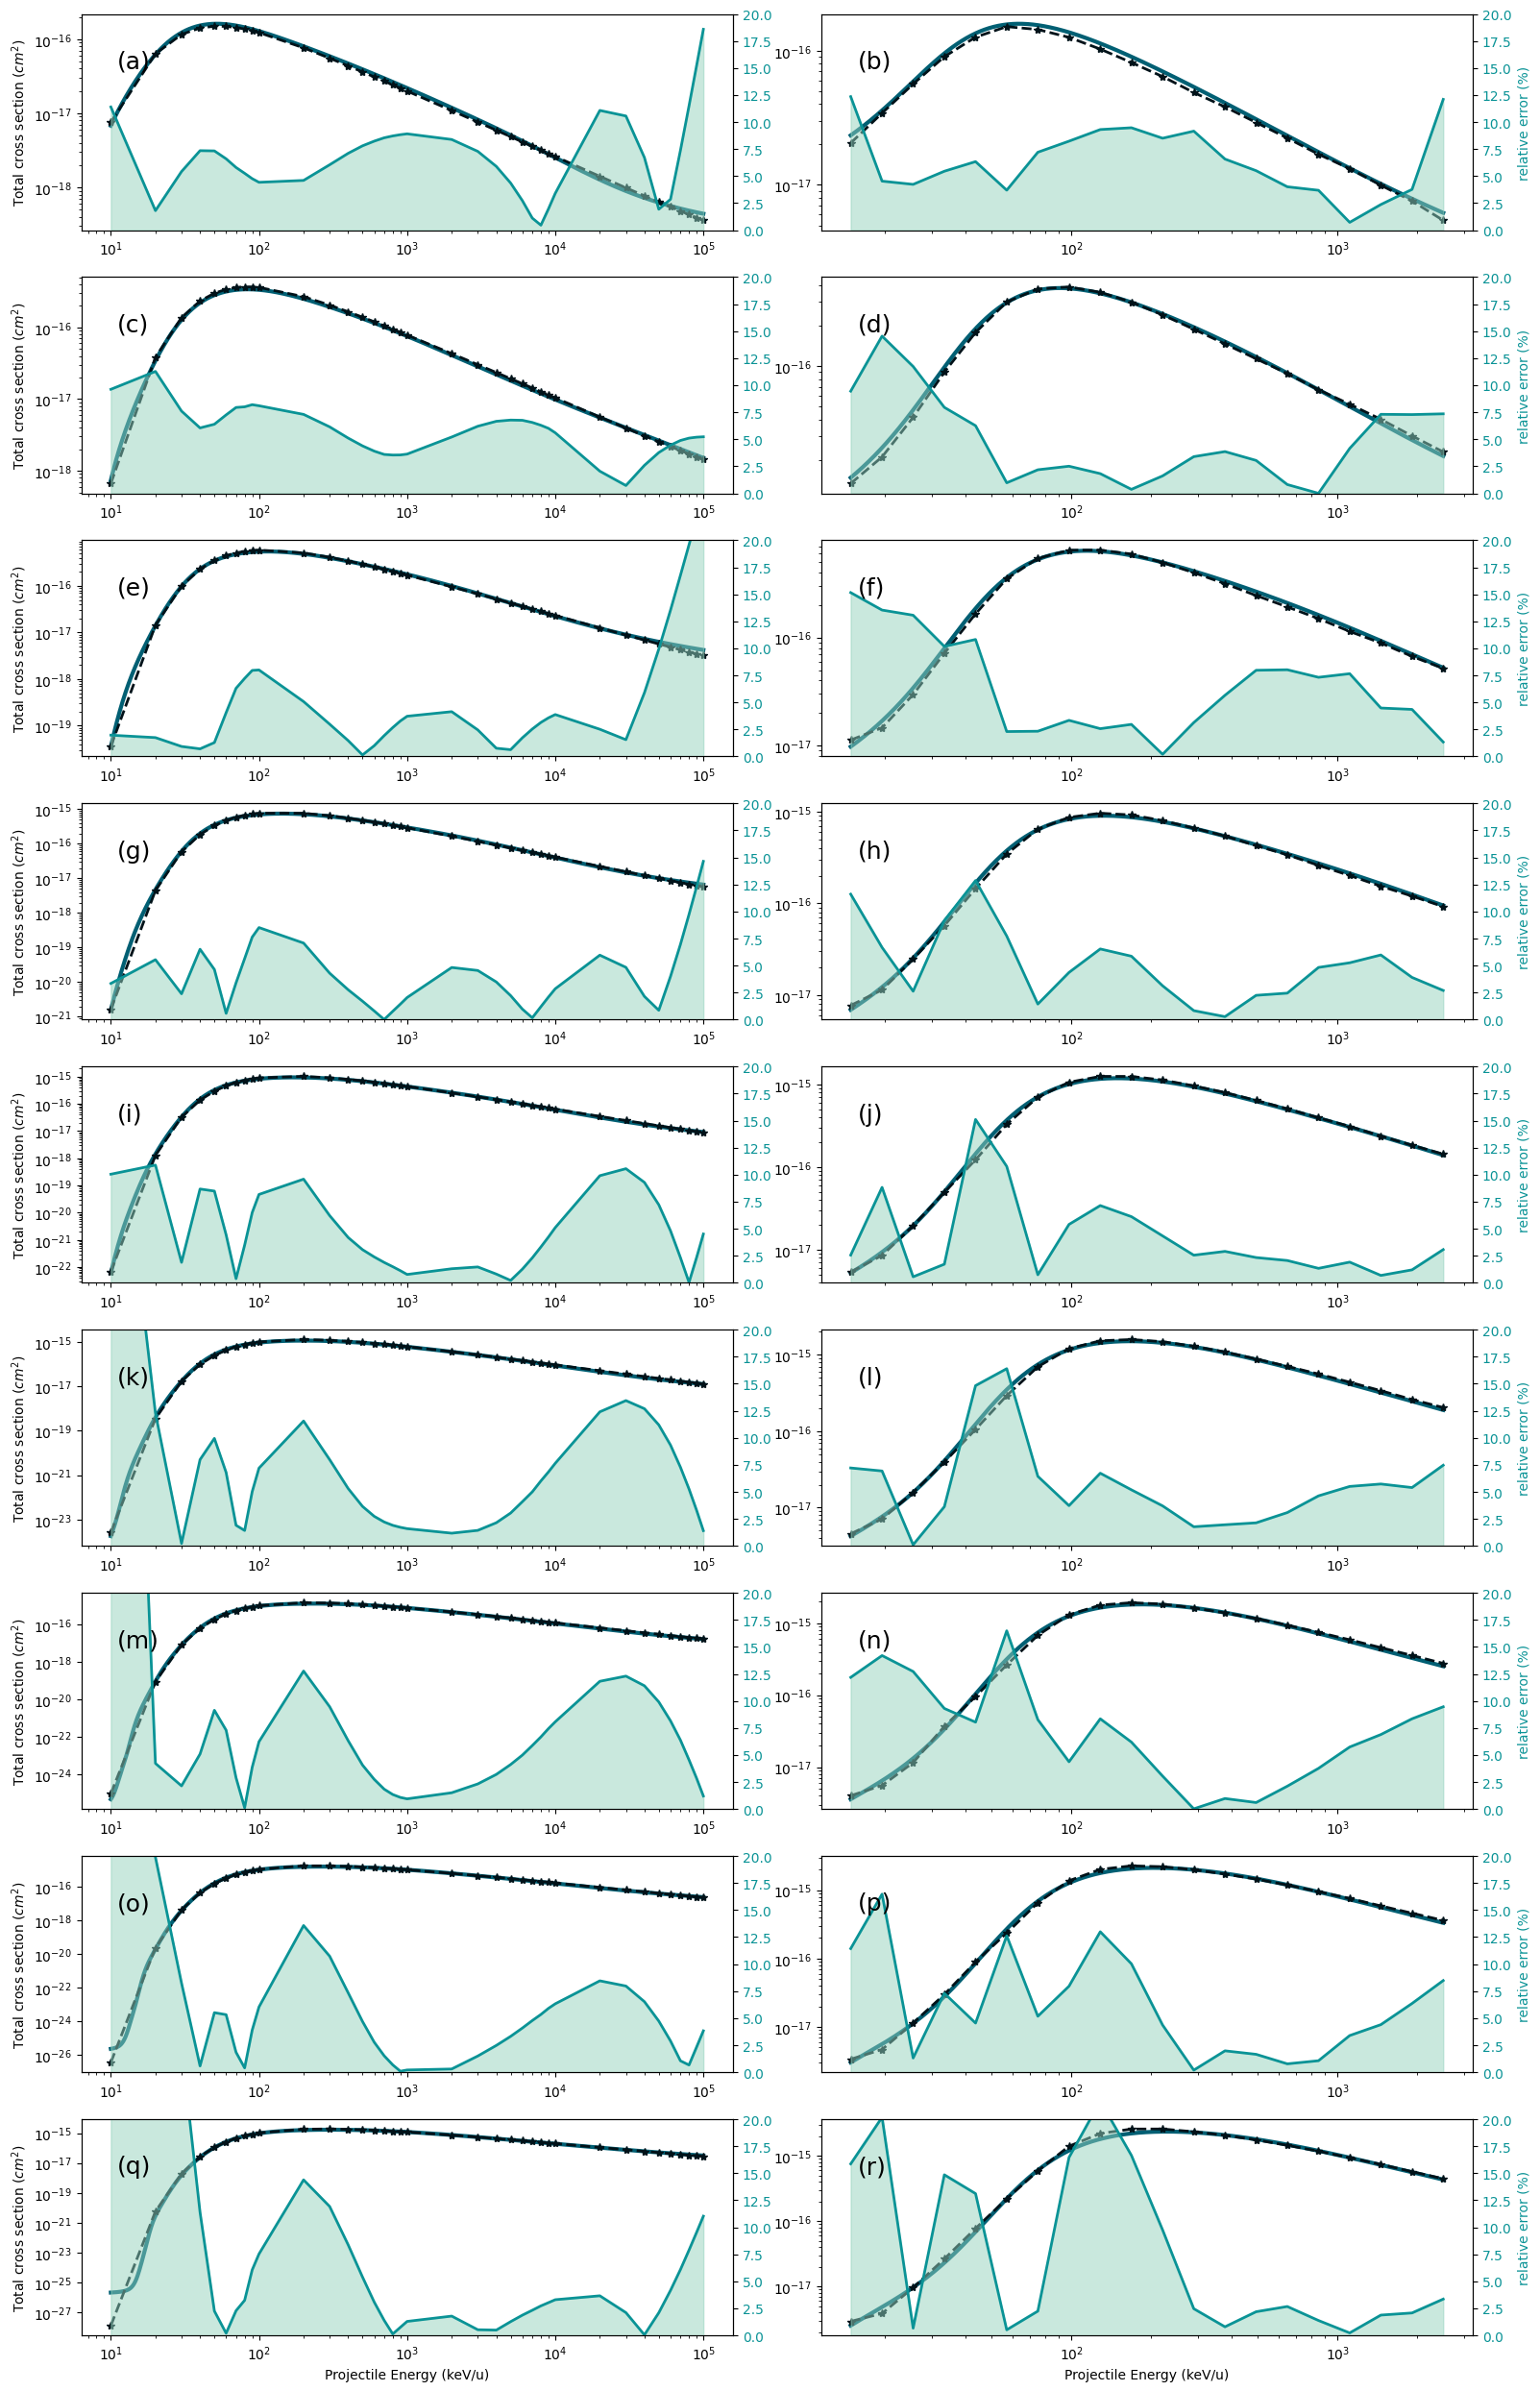

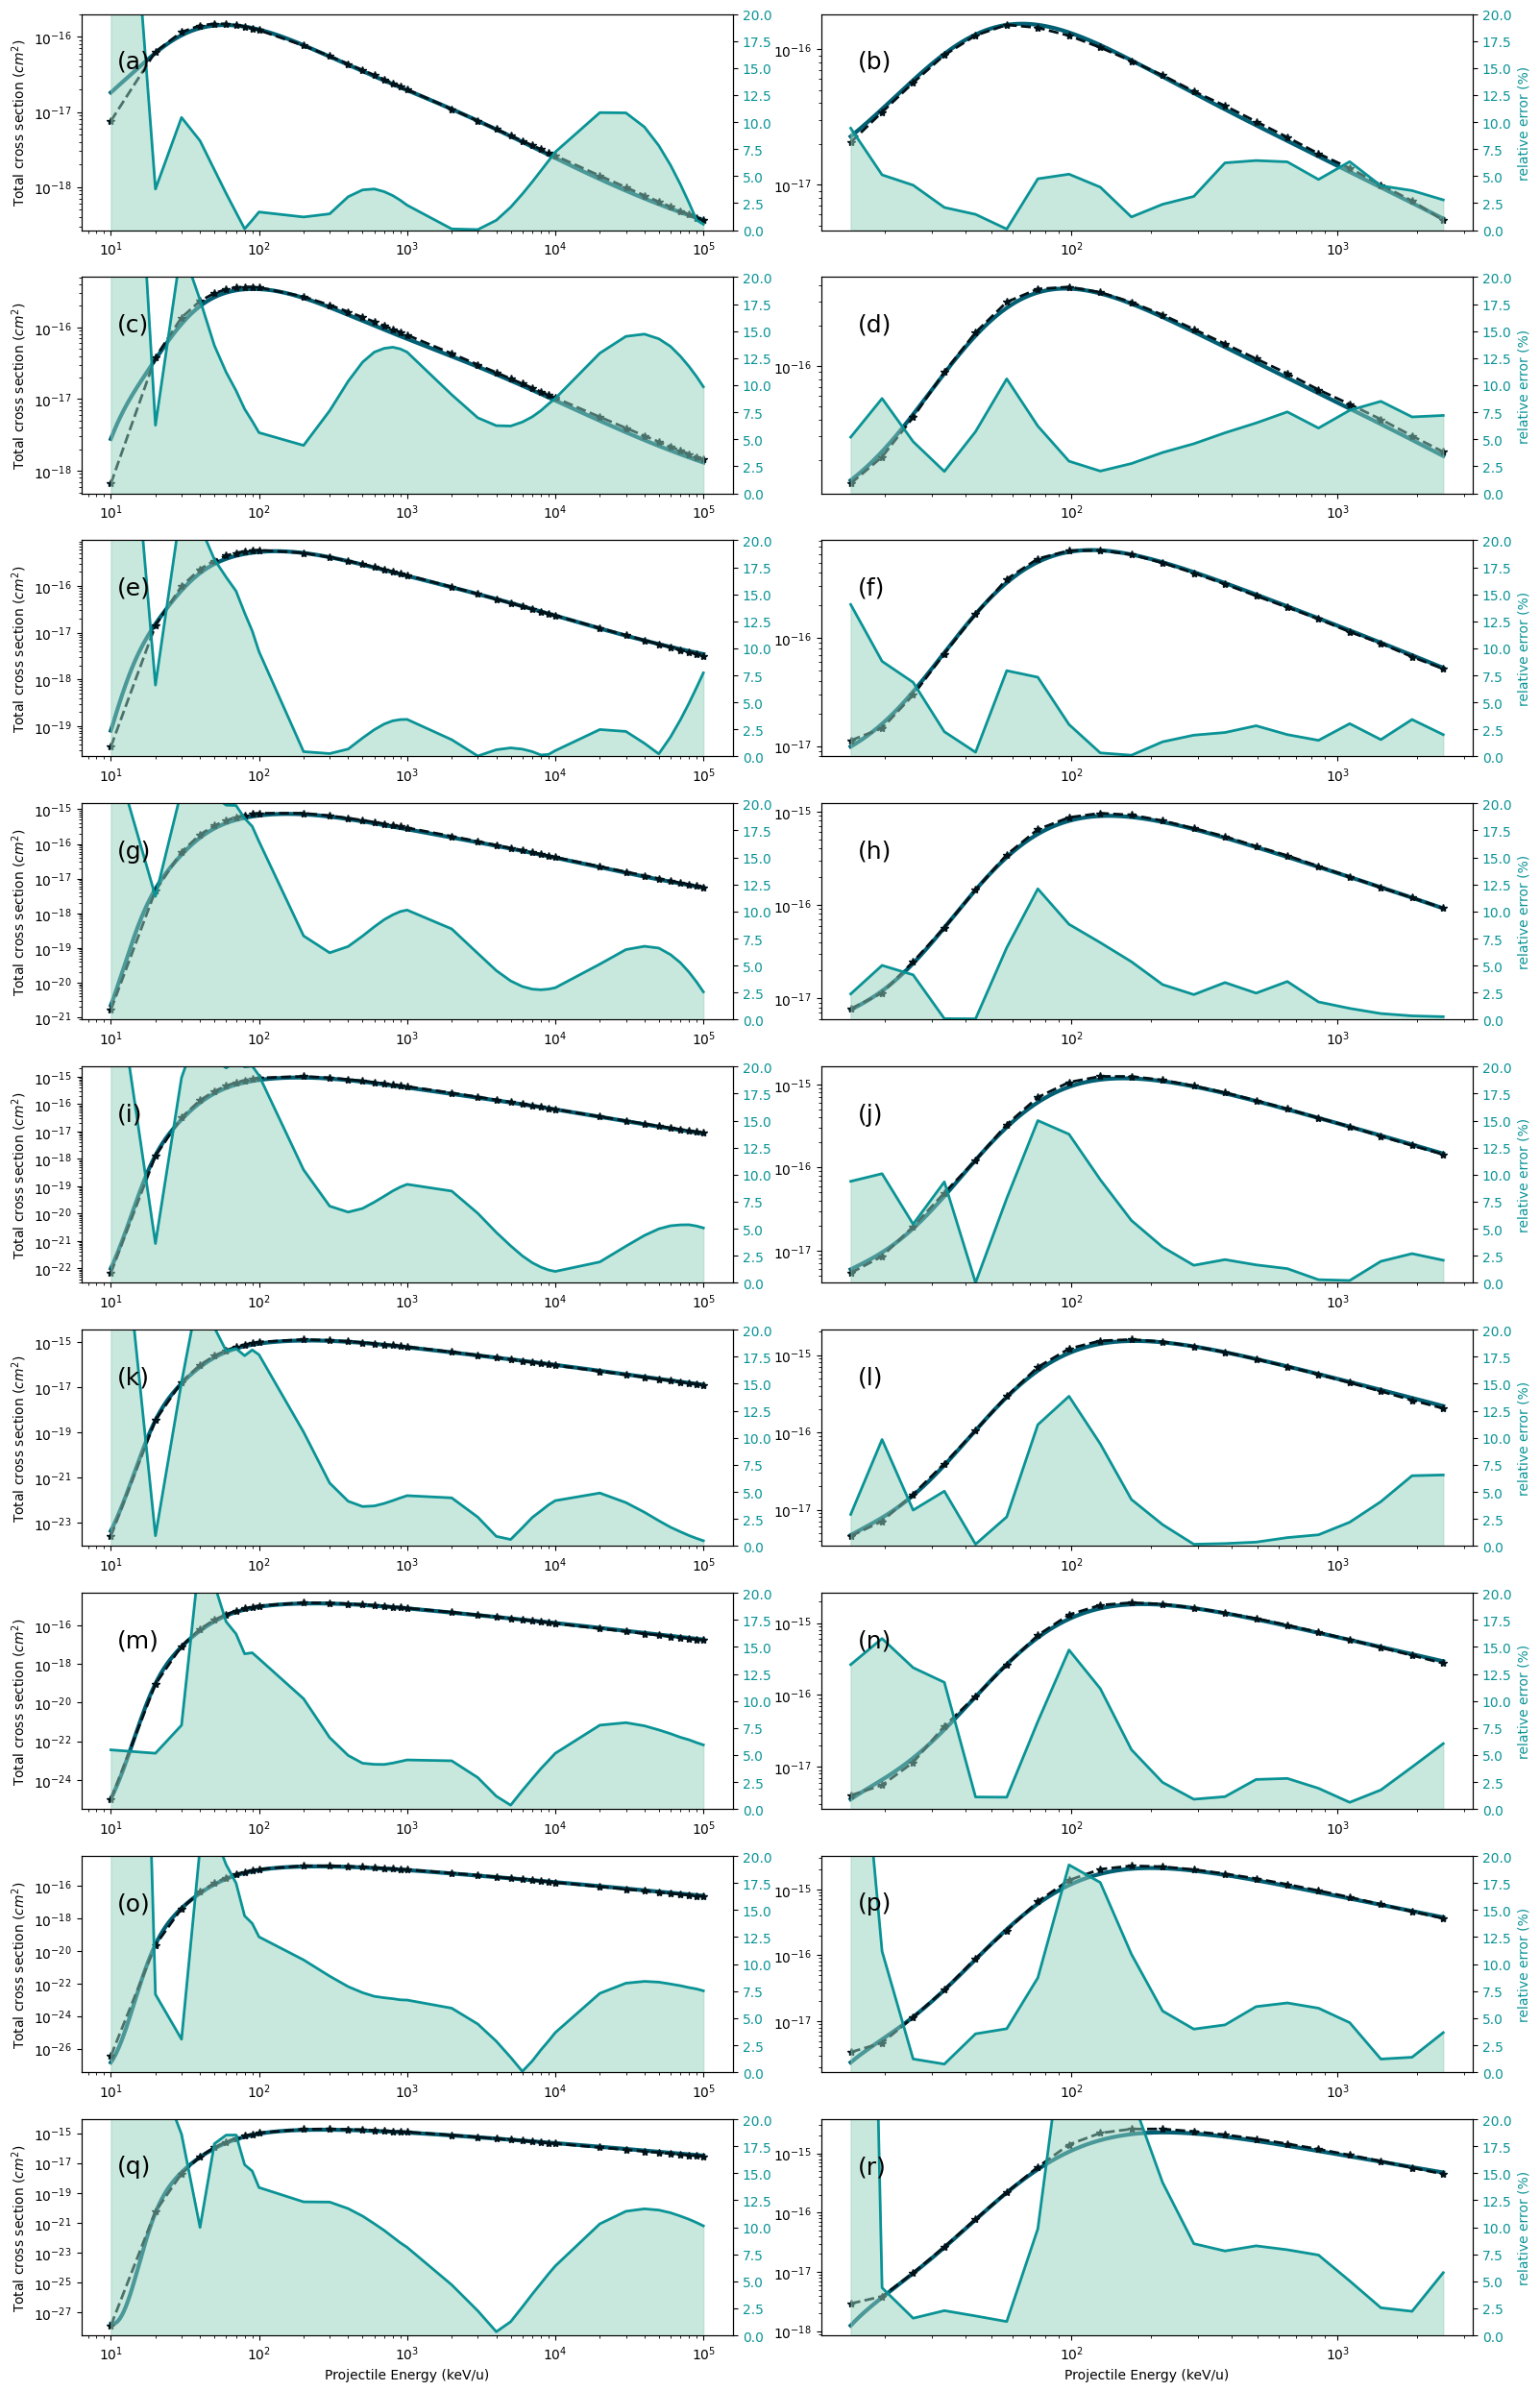

In [14]:
# Here we plot ground truth data vs real claculated data
labels_figs = ['(a)','(b)','(c)','(d)','(e)',
               '(f)','(g)','(h)','(i)','(j)',
               '(k)','(l)','(m)','(n)',
               '(o)','(p)','(q)','(r)',
               '(s)','(t)','(u)','(v)',]
df_theory_encoded = pd.DataFrame(theory_one_hot, columns=encoder.get_feature_names_out(['Theory_ID']))
hyd_df = pd.concat([hyd_df.reset_index(drop=True), df_theory_encoded], axis=1)
for act in ['tanh', 'gauss']:

    model = FlexibleNN(6, 128, act, 0.0)
    model.load_state_dict(torch.load(os.path.join(MODEL_FOLDER,'best_statedict_'+act+'_128_128_128_hole_3.pth'),map_location=DEVICE))
    model.eval()

    fig, axes = plt.subplots(9, 2, figsize=(16, 25))

    idx_row = 0
    for z_ion in range(1,10):
        idx_col = 0
        for theory in ['CDW-EIS', 'CTMC']:
            aux = hyd_df[hyd_df['Theory_ID'] == theory]
            x = aux[aux['Z_ion'] == z_ion]['E_proj[keV/u]'].values
            y = aux[aux['Z_ion'] == z_ion]['Cross_section[cm2]'].values
            y_pred = predict_conditional(model, encoder, theory, z_ion, 1, np.log10(x)).reshape(-1)
            x_to_predict = torch.logspace(np.log10(np.min(x)),
                                            np.log10(np.max(x)),
                                            1000)
            y_pred_lp = predict_conditional(model, encoder, theory, z_ion, 1, np.log10(x_to_predict)).reshape(-1)
            error = rel_err(y, 10**y_pred)*100

            axes[idx_row,idx_col].loglog(x_to_predict, 10**y_pred_lp, lw = 3, 
                                         color= colorlist3[1], 
                                         label = f'MLP {theory}' )

            axes[idx_row,idx_col].loglog(x, y, '*--', lw = 2, color= colorlist3[0],
                                         label = f'Theory {theory}' )

            ax_right = axes[idx_row,idx_col].twinx()
            ax_right.semilogx(x, error, c = colorlist3[2], lw = 2)
            ax_right.fill_between(x, error,color = colorlist3[3], alpha = 0.5)
            
            ax_right.tick_params(axis='y', labelcolor=colorlist3[2])
            ax_right.set_ylim(0,20)
            ax_right.text(x.min()+1, 15, labels_figs[idx_col+idx_row*2], fontsize=18)

            # axes[idx_row,idx_col].legend()
            idx_col += 1
        ax_right.set_ylabel('relative error (%)', color=colorlist3[2])
        axes[idx_row,0].set_ylabel(r'Total cross section ($cm^2$)' )
        idx_row +=1
        axes[8,0].set_xlabel('Projectile Energy (keV/u)')
        axes[8,1].set_xlabel('Projectile Energy (keV/u)')
    fig.tight_layout()
    plt.savefig('./performance_'+act+'.png')


In [15]:
X_conditional = np.hstack([
    hyd_df[['Z_ion', 'Z_target', 'log_E']].values,
    theory_one_hot
])
y_conditional = hyd_df['log_sigma'].values

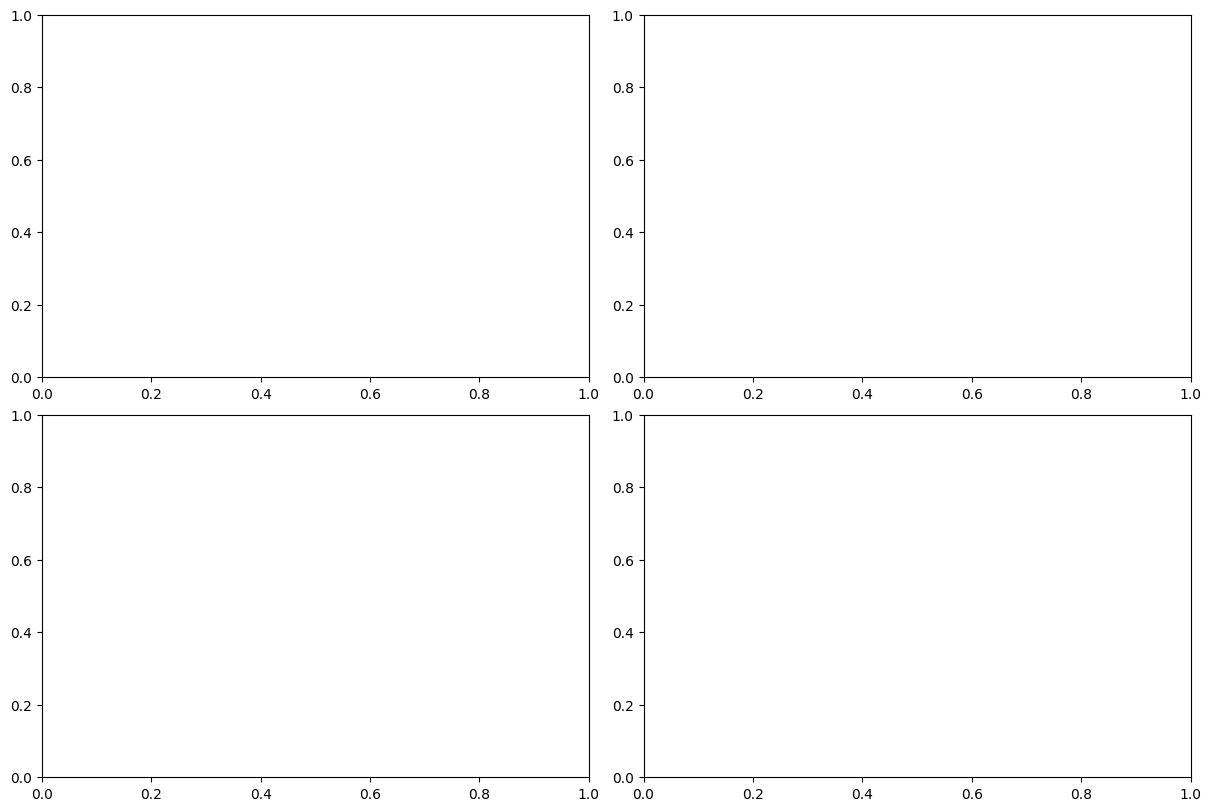

In [16]:
# 1. Crear la figura de 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

